In [2]:
import pandas as pd
import pygmt
import xarray as xr
import os
import math
import numpy as np

DEM already exists!


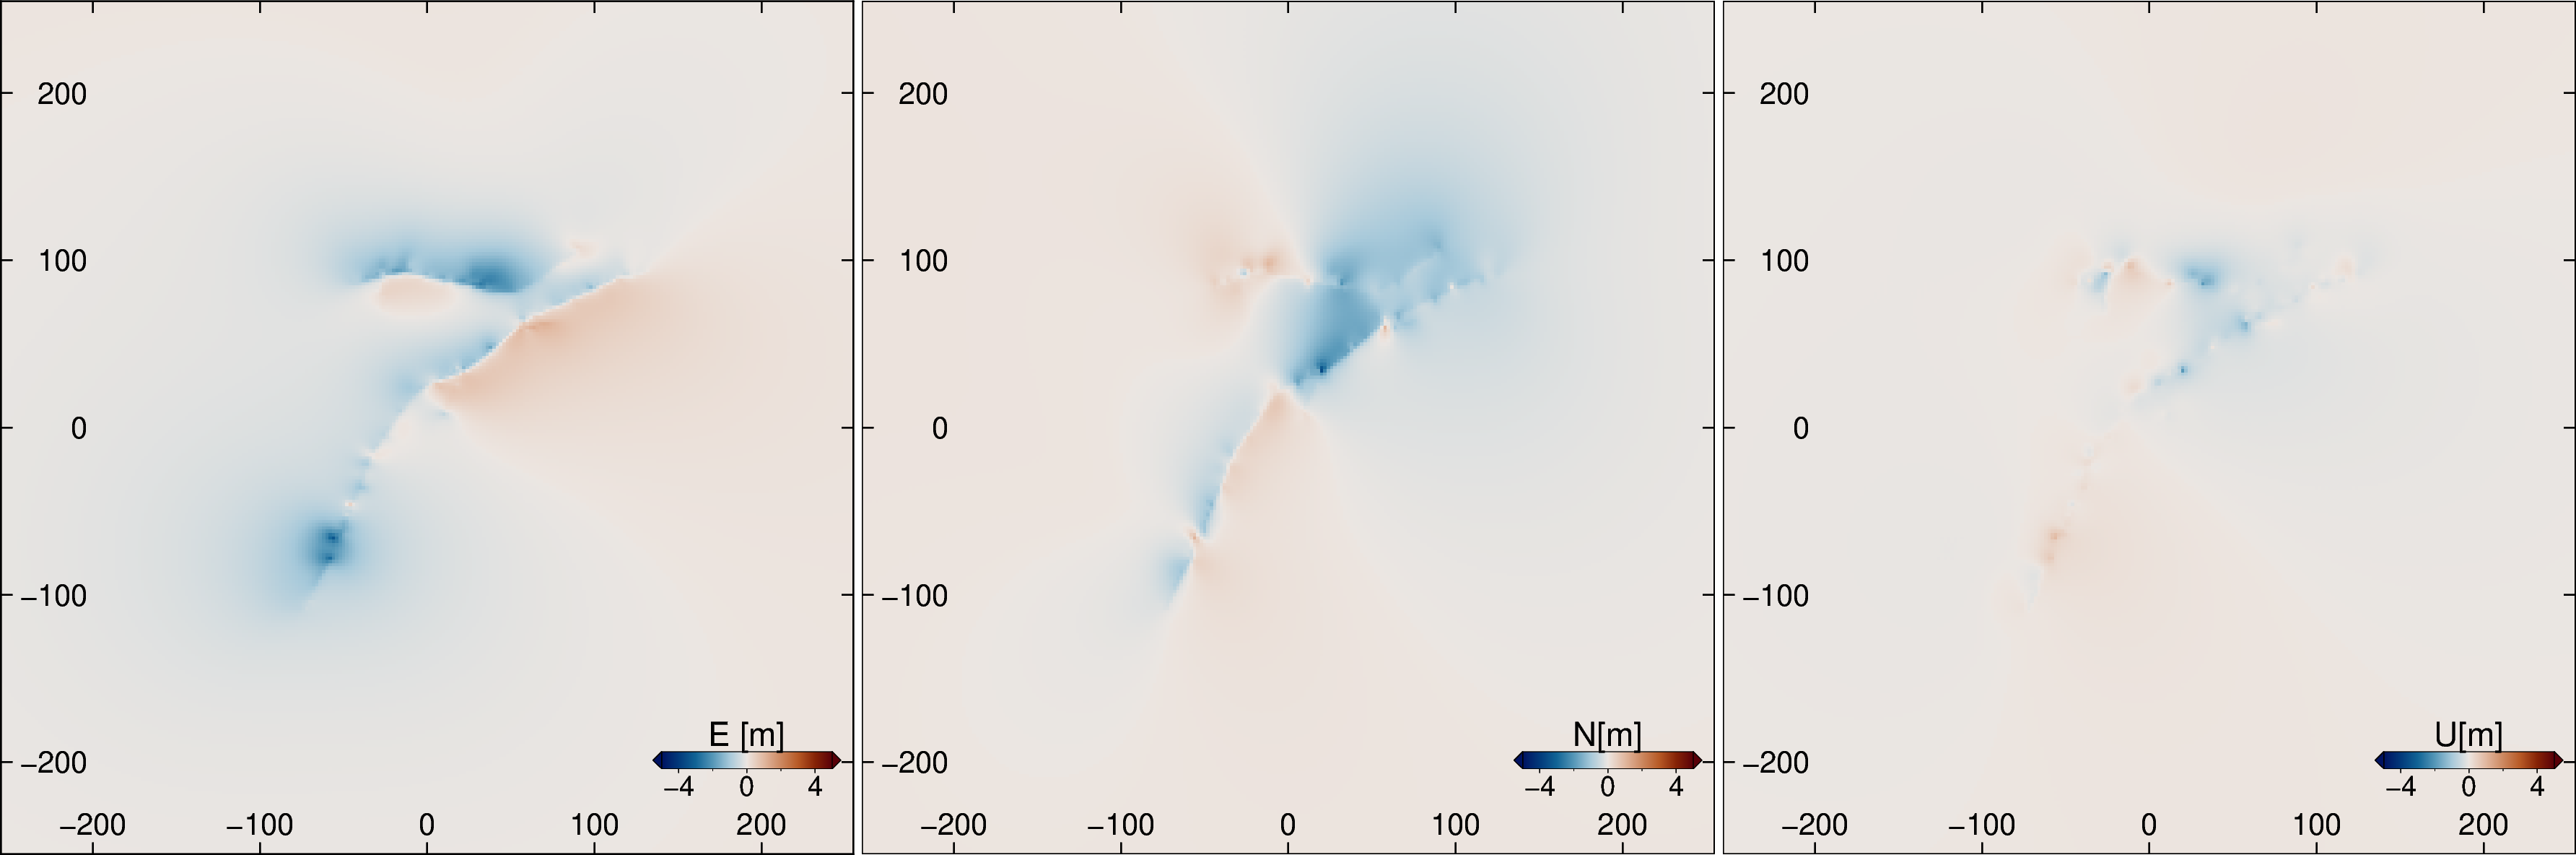

In [34]:
# -----------------------------------------------------------------------------
# Region
lonmin_lamb = 1  # degrees East
lonmax_lamb = 80
latmin_lamb = 25
latmax_lamb = 60
RR_used = [lonmin_lamb, lonmax_lamb, latmin_lamb, latmax_lamb]

region_TR = [-255, 255, -255, 255]

dem_file='earth_relief_fullAHB_30s.nc'
# Upload data
batchdir = '/scratch/eemne/'
dem = os.path.join(batchdir, dem_file)
dem_resolution='30s'
GEMS_dir='/scratch/eemne/GEMS'
fault_file=f'{GEMS_dir}/GEM_NAEF.shp'

#####
# DEM downloading
if not os.path.exists(dem):
    print('DEM is downloading please wait! After downloading, the process will be faster!')
    try:
        # Download the earth relief data and save it to a file
        grid = pygmt.datasets.load_earth_relief(resolution=dem_resolution, region=RR_used)
        # Saving the grid to a NetCDF file
        grid.to_netcdf(dem)
        print(f"Data successfully downloaded and saved to {dem}")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print(f'DEM already exists!')

fig = pygmt.Figure()
pygmt.config(
    MAP_FRAME_TYPE="plain",
    FONT_ANNOT_PRIMARY="25p,Helvetica,black",   # longitude ticks
    FONT_LABEL="30p,Helvetica,black",       # axis labels
    FORMAT_GEO_MAP='D',
    MAP_FRAME_PEN="0.5p,black"  # 2-point thick black frame line
)

####First
fig.basemap(projection="X10c", region=region_TR, frame=['WSne'])
###colorbar
pygmt.makecpt(cmap='vik', series=[-5, 5, 1], continuous=True, reverse=False)

# PLOT asc_file
# First layer: with shading (but no transparency)
#######---------second----------#######
workdir='/mnt/scratch/eemne/github/relax1/examples/2023_Kahramanmaras/coseismic-turkey2023_120km'
fig.grdimage(grid=f'{workdir}/000-east.grd', cmap=True)#, shading=True)
# #plot faults

###colorbar
fig.colorbar(
    frame='a4f2+lE [m]',  # Label for the color bar
    cmap=True,
    position="JBC+o3.75c/-1.2c+w2c/0.20c+ml+h+e",  # Adjust position
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

# ###lastbasemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="10p,Helvetica,black")
fig.basemap(projection="X10c", region=region_TR, frame=["x100f200","y100f200",'WSne'])


#####--------second----------#######

fig.shift_origin(xshift="10.1c", yshift="0c")
fig.basemap(projection="X10c", region=region_TR, frame=['WSne'])
###colorbar
pygmt.makecpt(cmap='vik', series=[-5, 5, 1], continuous=True, reverse=False)

# PLOT asc_file
# First layer: with shading (but no transparency)
#######---------second----------#######

fig.grdimage(grid=f'{workdir}/000-north.grd', cmap=True)#, shading=True)
# #plot faults

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT="25p,Helvetica,black")
fig.colorbar(
    frame='a4f2+lN[m]',  # Label for the color bar
    cmap=True,
    position="JBC+o3.75c/-1.2c+w2c/0.20c+ml+h+e",  # Adjust position
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

# ###lastbasemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT_PRIMARY="10p,Helvetica,black")
fig.basemap(projection="X10c", region=region_TR, frame=["x100f200","y100f200",'WSne'])


#####--------third----------#######
fig.shift_origin(xshift="10.1c", yshift="0c")
fig.basemap(projection="X10c", region=region_TR, frame=['WSne'])
###colorbar
pygmt.makecpt(cmap='vik', series=[-5, 5, 1], continuous=True, reverse=False)

# PLOT asc_file
# First layer: with shading (but no transparency)

fig.grdimage(grid=f'{workdir}/000-up.grd', cmap=True)#, shading=True)
# #plot faults

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT="25p,Helvetica,black")
fig.colorbar(
    frame='a4f2+lU[m]',  # Label for the color bar
    cmap=True,
    position="JBC+o3.75c/-1.2c+w2c/0.20c+ml+h+e",  # Adjust position
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

# ###lastbasemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT_PRIMARY="10p,Helvetica,black")
fig.basemap(projection="X10c", region=region_TR, frame=["x100f200","y100f200",'WSne'])







fig.show()